# Hyperliquid BTC Trade Analysis with `polaris_data`

This notebook uses `polaris-data>=0.8.6` to:

- discover the Hyperliquid BTC market in Polaris
- inspect the available catalog coverage window
- fetch matching OHLCV bars and trade data
- plot price and trade flow for quick inspection


## Setup
This repository already pins `polaris-data`, `pandas`, and `matplotlib` in `pyproject.toml`.

Run `make install` once from the repo root, then start JupyterLab with `make notebook`. The analysis below derives its query window from the catalog metadata so it stays aligned with the data currently available in Polaris.


In [15]:
from polaris_data import PolarisClient
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-darkgrid")

In [16]:
source = "hyperliquid"
market = "BTC"


## Discover market metadata
Start with `client.catalog(...)` to confirm the market exists in Polaris and inspect the returned metadata before fetching time-series data.


In [17]:
with PolarisClient() as client:
    catalog = client.catalog(source=source, market=market)

market_info = catalog["markets"][0]
available_start = pd.Timestamp(market_info["start"])
available_end = pd.Timestamp(market_info["end"])

print(f"Catalog coverage: {available_start} -> {available_end}")
market_info


Catalog coverage: 2026-07-11 10:26:03.874000+00:00 -> 2026-07-12 00:39:28.083000+00:00


{'source': 'hyperliquid',
 'market': 'BTC',
 'start': '2026-07-11T10:26:03.874Z',
 'end': '2026-07-12T00:39:28.083Z',
 'categories': ['perp'],
 'access': {'status': 'open', 'public_cutoff_date': None},
 'instrument': {'base': 'BTC',
  'quote': 'USD',
  'tick_size': None,
  'lot_size': '0.00001',
  'min_notional': None}}

## Fetch bars and trades
Use the catalog-reported coverage window for both `ohlcv(...)` and `trades(...)` so the summary statistics and chart line up with the data that is currently available.


In [18]:
with PolarisClient() as client:
    bars = client.ohlcv(
        source=source,
        market=market,
        interval="1m",
        from_=available_start,
        to=available_end,
        allow_gaps=True,
    )
    trades = client.trades(
        source=source,
        market=market,
        from_=available_start,
        to=available_end,
    )


In [19]:
bars_df = pd.DataFrame(bars)
if bars_df.empty:
    bars_df = pd.DataFrame(columns=["timestamp", "open", "high", "low", "close", "volume", "trades", "interval"])
bars_df["timestamp"] = pd.to_datetime(bars_df["timestamp"], unit="ms", utc=True)
bars_df = bars_df.set_index("timestamp").sort_index()

trades_df = pd.json_normalize(trades)
if trades_df.empty:
    trades_df = pd.DataFrame(columns=["timestamp", "data.price", "data.quantity", "data.side"])
trades_df["timestamp"] = pd.to_datetime(trades_df["timestamp"], unit="ms", utc=True)
trades_df = trades_df.rename(
    columns={
        "data.price": "price",
        "data.quantity": "quantity",
        "data.side": "side",
    }
)
trades_df = trades_df.sort_values("timestamp")

if not bars_df.empty:
    print(f"Bars returned: {bars_df.index.min()} -> {bars_df.index.max()} ({len(bars_df)} rows)")
if not trades_df.empty:
    print(f"Trades returned: {trades_df['timestamp'].min()} -> {trades_df['timestamp'].max()} ({len(trades_df)} rows)")

trades_df[["timestamp", "price", "quantity", "side"]].head()

Bars returned: 2026-07-11 10:26:00+00:00 -> 2026-07-12 00:39:00+00:00 (840 rows)
Trades returned: 2026-07-11 10:26:09.782000+00:00 -> 2026-07-12 00:39:27.002000+00:00 (105232 rows)


,timestamp,price,quantity,side
0,2026-07-11 10:26:09.782000+00:00,64169.0,0.00029,sell
1,2026-07-11 10:26:10.588000+00:00,64170.0,0.00001,buy
2,2026-07-11 10:26:11.397000+00:00,64170.0,0.00138,buy
3,2026-07-11 10:26:15.039000+00:00,64170.0,0.00018,buy
4,2026-07-11 10:26:16.268000+00:00,64169.0,0.00138,sell


In [20]:
trade_summary = pd.DataFrame(
    {
        "trade_count": [len(trades_df)],
        "buy_volume": [trades_df.loc[trades_df["side"] == "buy", "quantity"].sum()],
        "sell_volume": [trades_df.loc[trades_df["side"] == "sell", "quantity"].sum()],
        "notional_usd": [(trades_df["price"] * trades_df["quantity"]).sum()],
    }
)
trade_summary

,trade_count,buy_volume,sell_volume,notional_usd
0,105232,3604.68599,3097.36229,4.302844e+08


## Visualize price and signed trade flow
The final chart overlays minute closes with buy and sell prints, then aggregates signed trade quantity by minute to highlight directional pressure.


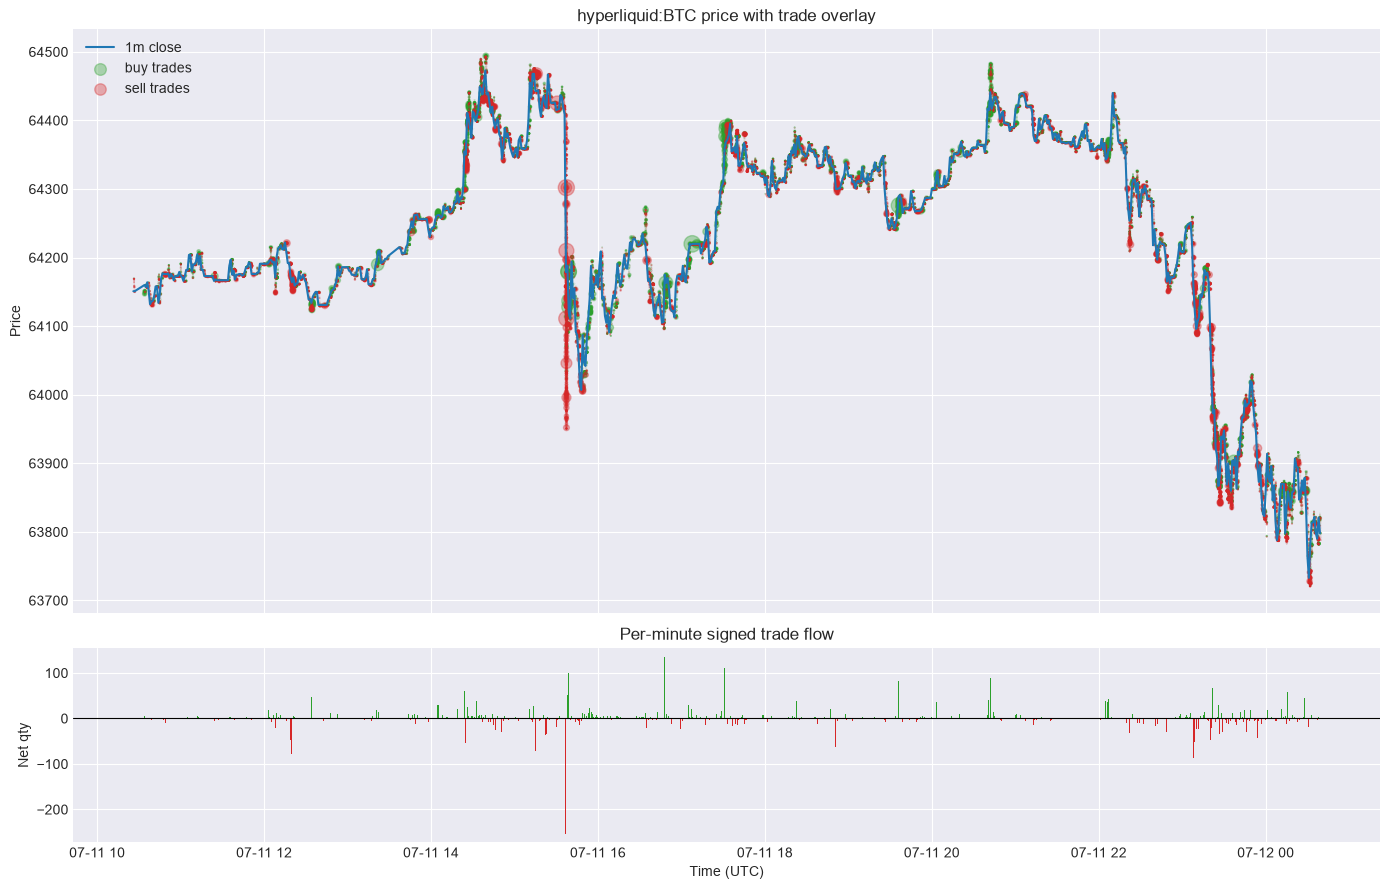

In [21]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 9),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
)

axes[0].plot(bars_df.index, bars_df["close"], color="#1f77b4", linewidth=1.5, label="1m close")

buy_trades = trades_df[trades_df["side"] == "buy"]
sell_trades = trades_df[trades_df["side"] == "sell"]

axes[0].scatter(
    buy_trades["timestamp"],
    buy_trades["price"],
    s=buy_trades["quantity"] * 8,
    alpha=0.35,
    color="#2ca02c",
    label="buy trades",
)
axes[0].scatter(
    sell_trades["timestamp"],
    sell_trades["price"],
    s=sell_trades["quantity"] * 8,
    alpha=0.35,
    color="#d62728",
    label="sell trades",
)
axes[0].set_title(f"{source}:{market} price with trade overlay")
axes[0].set_ylabel("Price")
axes[0].legend(loc="upper left")

trade_flow = (
    trades_df.assign(
        signed_qty=trades_df["quantity"].where(trades_df["side"] == "buy", -trades_df["quantity"])
    )
    .set_index("timestamp")["signed_qty"]
    .resample("1min")
    .sum()
    .fillna(0)
)
bar_colors = trade_flow.apply(lambda value: "#2ca02c" if value >= 0 else "#d62728")
axes[1].bar(trade_flow.index, trade_flow.values, width=0.0005, color=bar_colors)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("Net qty")
axes[1].set_xlabel("Time (UTC)")
axes[1].set_title("Per-minute signed trade flow")

plt.tight_layout()
plt.show()